【原始高维特征直接分类准确率】：0.9804
【PCA】耗时：0.5223s 分类准确率：0.5913
【MDA(LDA)】耗时：0.3560s 分类准确率：0.6625
【KPCA】耗时：0.5193s 分类准确率：0.6186
【ISOMAP】耗时：0.2911s 分类准确率：0.7598
【T-SNE】耗时：0.1404s 分类准确率：0.9715


D:\python\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


【UMAP】耗时：0.0250s 分类准确率：0.9994

===== 各算法降维优化分类任务结果汇总 =====
         算法  运行时间(s)   分类准确率
0       PCA   0.5223  0.5913
1  MDA(LDA)   0.3560  0.6625
2      KPCA   0.5193  0.6186
3    ISOMAP   0.2911  0.7598
4     T-SNE   0.1404  0.9715
5      UMAP   0.0250  0.9994


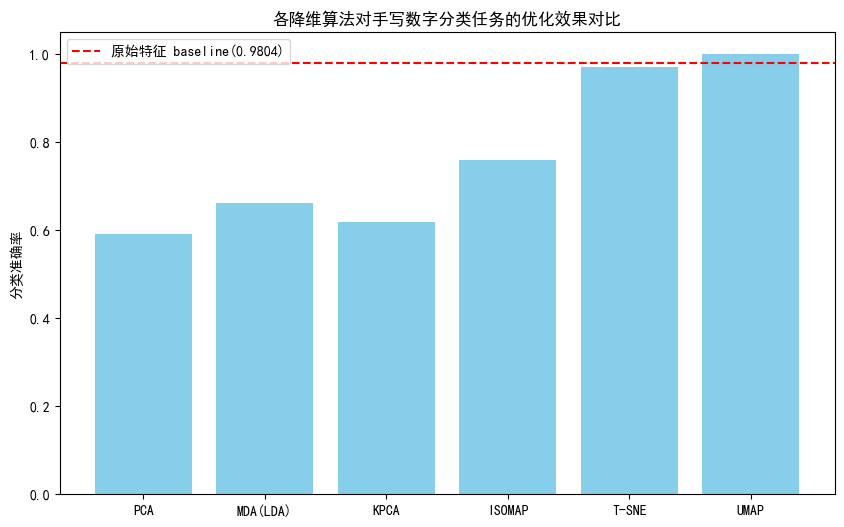

In [2]:
# 导入工具库
import time
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import Isomap, TSNE
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import umap
import matplotlib.pyplot as plt
# 解决中文显示
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "SimSun"]
# 解决负号显示异常
plt.rcParams["axes.unicode_minus"] = False

# 加载UCI手写数字高维数据集
data = fetch_ucirepo(id=80)
X = data.data.features
y = data.data.targets.values.ravel()

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集、测试集（用于分类任务）
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# ---------- 基线实验：原始64维特征直接分类 ----------
svm_baseline = SVC()
svm_baseline.fit(X_train, y_train)
y_pred_base = svm_baseline.predict(X_test)
base_acc = accuracy_score(y_test, y_pred_base)
print(f"【原始高维特征直接分类准确率】：{base_acc:.4f}")

# 定义6种降维算法
dim_models = {
    "PCA": PCA(n_components=2),
    "MDA(LDA)": LinearDiscriminantAnalysis(n_components=2),
    "KPCA": KernelPCA(n_components=2, kernel="rbf", gamma=0.05),
    "ISOMAP": Isomap(n_components=2, n_neighbors=10),
    "T-SNE": TSNE(n_components=2, random_state=42),
    "UMAP": umap.UMAP(n_components=2, random_state=42)
}

acc_results = []

# ---------- 降维后 + SVM分类 解决分类问题 ----------
for name, model in dim_models.items():
    # 降维
    X_all_dim = model.fit_transform(X_scaled, y)
    X_train_dim, X_test_dim, y_train_dim, y_test_dim = train_test_split(X_all_dim, y, test_size=0.3, random_state=42)
    
    # 计时并分类
    t1 = time.time()
    svm = SVC()
    svm.fit(X_train_dim, y_train_dim)
    y_pred = svm.predict(X_test_dim)
    t2 = time.time()
    
    acc = accuracy_score(y_test_dim, y_pred)
    acc_results.append([name, round(t2-t1,4), round(acc,4)])
    print(f"【{name}】耗时：{t2-t1:.4f}s 分类准确率：{acc:.4f}")

# 结果汇总
df = pd.DataFrame(acc_results,columns=["算法","运行时间(s)","分类准确率"])
print("\n===== 各算法降维优化分类任务结果汇总 =====")
print(df)

# 可视化准确率对比
plt.figure(figsize=(10,6))
plt.bar(df["算法"],df["分类准确率"],color="skyblue")
plt.axhline(base_acc,color="red",linestyle="--",label=f"原始特征 baseline({base_acc:.4f})")
plt.title("各降维算法对手写数字分类任务的优化效果对比")
plt.ylabel("分类准确率")
plt.legend()
plt.show()